In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt

# Load saved model and features
with open("data/credit_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("data/feature_list.pkl", "rb") as f:
    features = pickle.load(f)

df = pd.read_csv("data/application_train_features.csv")

X = df[features]
y = df["TARGET"]

print("Model loaded ✅")
print("Features:", len(features))
print("Applicants:", len(X))

Model loaded ✅
Features: 26
Applicants: 307511


In [2]:
# TreeExplainer is optimised for XGBoost — very fast
explainer = shap.TreeExplainer(model)

# Use a sample of 500 for speed — enough to see all patterns
sample_idx = df.sample(500, random_state=42).index
X_sample = X.loc[sample_idx]

shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape)
print("✅ One SHAP value per applicant per feature")

SHAP values shape: (500, 26)
✅ One SHAP value per applicant per feature


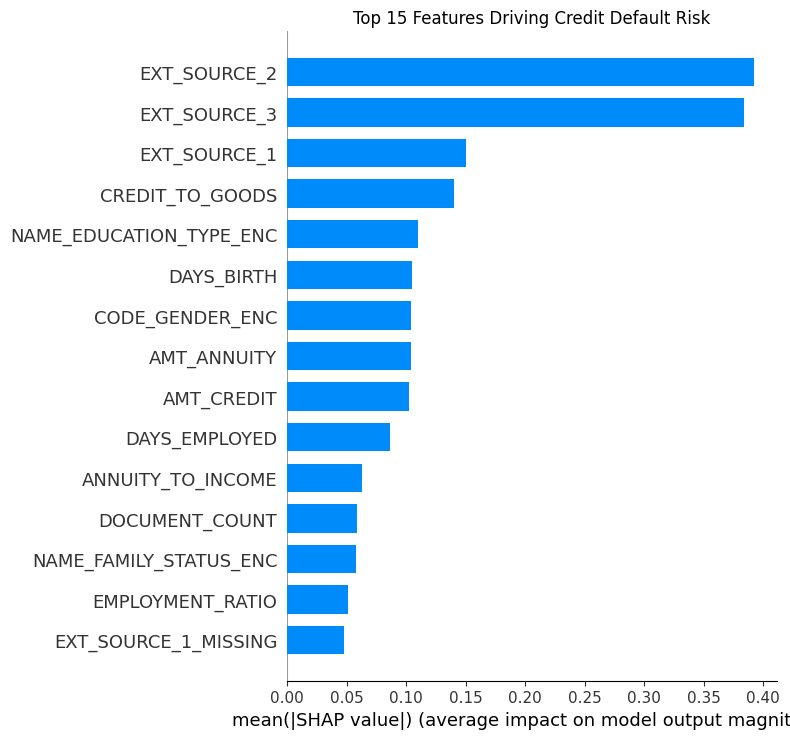

✅ Saved to data/shap_global_importance.png


In [3]:
# Summary plot — shows which features matter most across ALL applicants
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Top 15 Features Driving Credit Default Risk")
plt.tight_layout()
plt.savefig("data/shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to data/shap_global_importance.png")

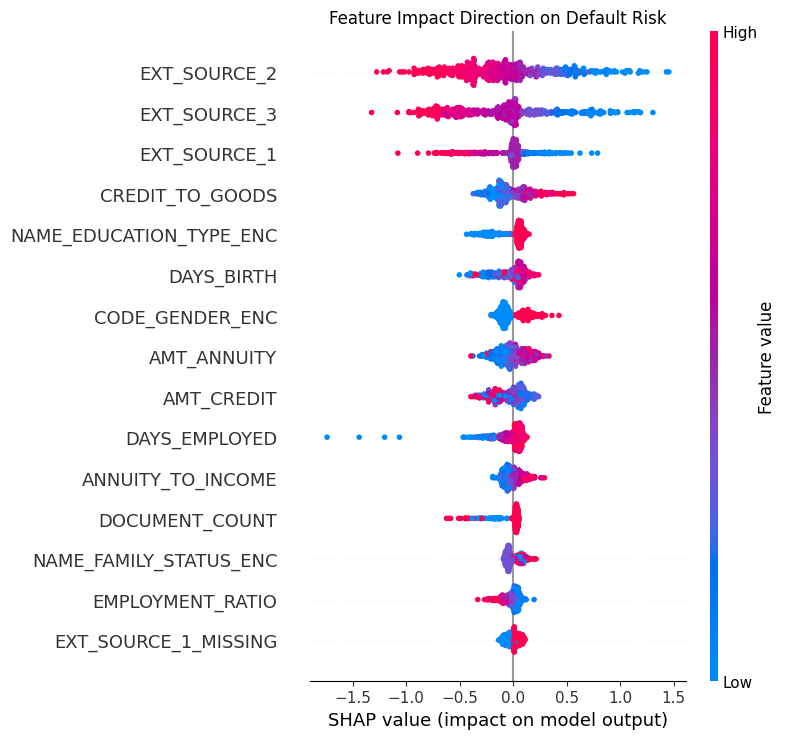

In [4]:
# This shows not just WHICH features matter but HOW they push the score
# Red = high feature value, Blue = low feature value
# Right = pushes toward default, Left = pushes away from default
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=15,
    show=False
)
plt.title("Feature Impact Direction on Default Risk")
plt.tight_layout()
plt.savefig("data/shap_dot_plot.png", dpi=150, bbox_inches="tight")
plt.show()

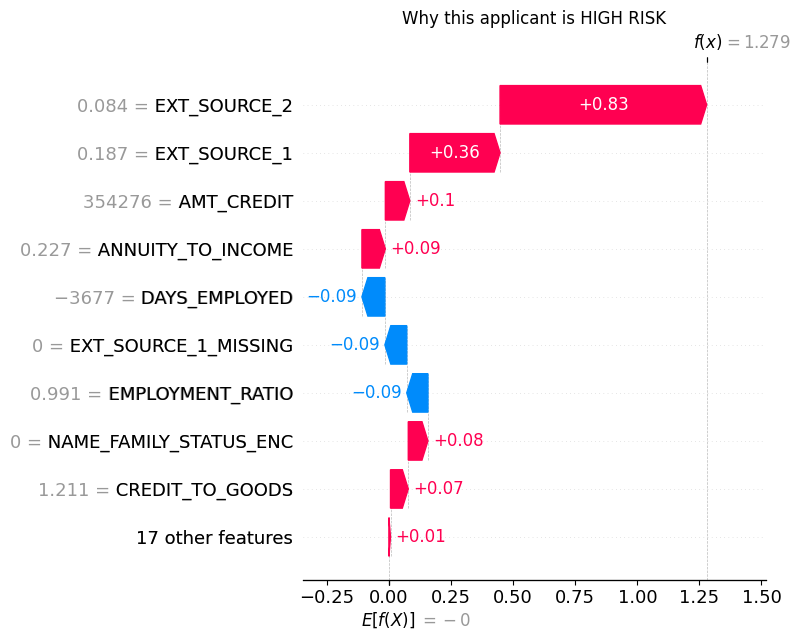

Applicant 71233 — Actual: DEFAULT
Risk score: 0.782


In [5]:
# Pick one real defaulter and one non-defaulter to explain individually
defaulter_idx = df[df["TARGET"] == 1].sample(1, random_state=42).index[0]
safe_idx = df[df["TARGET"] == 0].sample(1, random_state=42).index[0]

# Explain the defaulter
explanation = explainer(X.loc[[defaulter_idx]])

plt.figure()
shap.plots.waterfall(explanation[0], show=False)
plt.title("Why this applicant is HIGH RISK")
plt.tight_layout()
plt.savefig("data/shap_waterfall_defaulter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Applicant {defaulter_idx} — Actual: DEFAULT")
print(f"Risk score: {model.predict_proba(X.loc[[defaulter_idx]])[:,1][0]:.3f}")

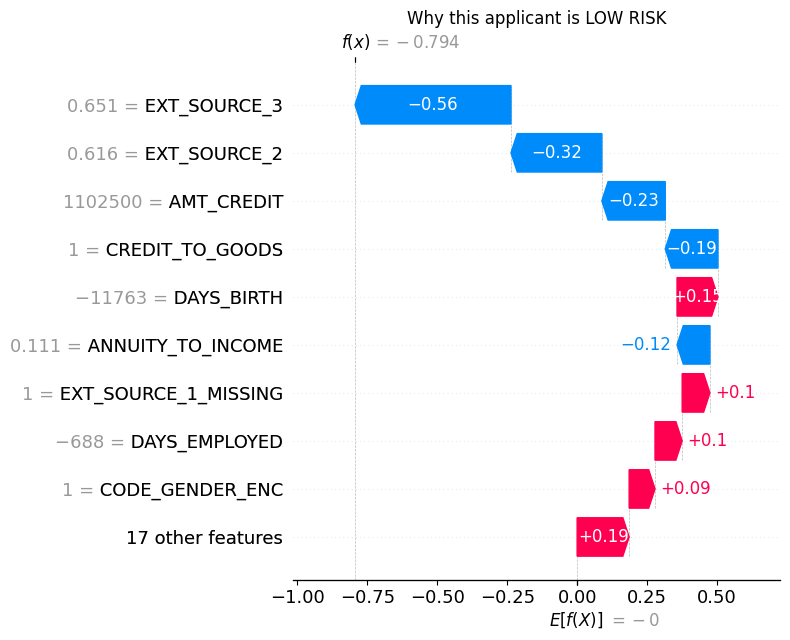

Applicant 201622 — Actual: REPAID
Risk score: 0.311


In [6]:
explanation_safe = explainer(X.loc[[safe_idx]])

plt.figure()
shap.plots.waterfall(explanation_safe[0], show=False)
plt.title("Why this applicant is LOW RISK")
plt.tight_layout()
plt.savefig("data/shap_waterfall_safe.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Applicant {safe_idx} — Actual: REPAID")
print(f"Risk score: {model.predict_proba(X.loc[[safe_idx]])[:,1][0]:.3f}")